## EMOBON Questions

This file was made to answer specific questions about emobon to see its capabilities for data harvesting and data management.
The questions posed originated from https://vliz.atlassian.net/wiki/spaces/VMDCOS/pages/204374034/First+setofqueriestorunon3storeofemobondata

The top level questions are as follows:

- 1: Give me the list of observatories: their names, country, location (lat, long and mrgid), and any habitat info
- 2: For each observatory now, give me the names, the number of sampling events for water and sediment and the overall date coverage, and the number of samples taken
- 3: For a named observatory (so I input the name), give me the number and percentage of missing information in the mandatory fields, per event (not per sample!). NA is “missing information, by the way so don’t throw them out. Plot or tabulate this per mandatory field name (as given in the logsheets)
- 4: And also the summary of the %coverage in the mandatory fields for the sampling tab (that is, the sampling tab of the googlesheet) and of the measured tab separately. do not throw out the NAs here.
- 5: For the mandatory measurements, give me the mean and mean deviation, as well as max and min values, for a named observatory (so I input the name), summed over all sampling events and over all water events separately (plots could be side-by-side). Give me this following the BODC names but then also output a list of BODC vs googlesheet names so I can read that off. Throw out the NAs here
- 6: Over all the observatories, list the samp_collect_devices used and the number of events (not samples) each was used for (I want to see how many different ones there are). Here you can throw out the NAs before reporting.
--> matched to query e (collect_device_usage)
- 7: For each observatory, how many samples for water and for sediment separately have been shipped to HQ
- 8: Identify the metagenomic sampling events taken in the English Channel (aka La Manche) during 2022-2023 where the sea temperature was below 10 degrees Celsius and the abundance of the taxon E. coli was > 2% (all of this is within the EMO BON data sets)

For each of these questions also make a query template that can be used for an and user to have some variables that can be used in UDAL.

In [1]:
pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [3]:
# import all stuff needed
from conneg_functions import execute_to_df, generate_sparql

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.core.display import HTML
import ipywidgets as widgets
from ipywidgets import interact
from IPython.display import display, clear_output
from sema.query import DefaultSparqlBuilder, GraphSource as KGSource, QueryResult
import os
from pandas import DataFrame

In [17]:
# some paramter setup for the triplestore
# SPARQL EndPoint to use - wrapped as Knowledge-Graph 'source'
GDB_BASE: str = os.getenv("GDB_BASE", "http://graphdb:7200/")
# print(f"{os.getenv('GDB_BASE')=}")
# print(f"{GDB_BASE=}")
GDB_REPO: str = os.getenv("GDB_REPO", "kgap")
GDB_ENDPOINT: str = f"{GDB_BASE}repositories/{GDB_REPO}"
# print(f"{GDB_ENDPOINT=}")
GDB: KGSource = KGSource.build(GDB_ENDPOINT)

# some css to format tables so that they are readable
HTML("""
<style>
    .dataframe td, .dataframe th {
        min-width: 500px;
        word-wrap: break-word;
    }
</style>
""")

In [4]:
# - 1: Give me the list of observatories: their names, country, location (lat, long and mrgid), and any habitat info

sparql_observatory = '''
PREFIX owl: <http://www.w3.org/2002/07/owl#> 
PREFIX sosa: <http://www.w3.org/ns/sosa/>
PREFIX emobon: <https://data.emobon.embrc.eu/ns/core#>
SELECT DISTINCT ?observatory 
(GROUP_CONCAT(DISTINCT ?marine_region; SEPARATOR="|") AS ?marine_regions)
(GROUP_CONCAT(DISTINCT ?marine_region_id; SEPARATOR="|") AS ?marine_region_ids)
(GROUP_CONCAT(DISTINCT ?country; SEPARATOR="|") AS ?countries)
(GROUP_CONCAT(DISTINCT ?biome; SEPARATOR="|") AS ?biomes)
WHERE  {
    ?observatory a emobon:Observatory .
    OPTIONAL { ?observatory emobon:originCountry ?country . }
    OPTIONAL { ?observatory emobon:marineRegionName ?marine_region . }
    OPTIONAL { ?observatory emobon:marineRegion ?marine_region_id . }
    OPTIONAL { ?observatory emobon:broadBiome ?biome . }
}
GROUP BY ?observatory
'''

result: QueryResult = GDB.query(sparql=sparql_observatory)
print(f"Result: {result=}")
df_observatory: DataFrame = result.to_dataframe()
df_observatory


Result: result=<sema.query.query.SPARQLQueryResult object at 0x7331a09baa50>


,observatory,marine_regions,marine_region_ids,countries,biomes
0,http://data.emobon.embrc.eu/observatory-oob-cr...,Mediterranean Sea - Western Basin|Gulf of Lion...,http://marineregions.org/mrgid/5207|http://mar...,France,marine%20biome%20%5BENVO:00000447%5D|marine%20...
1,http://data.emobon.embrc.eu/observatory-esc68n...,Norwegian part of the Norwegian Sea|Arctic Oce...,http://marineregions.org/mrgid/25242|http://ma...,Norway,marine%20biome%20%5BENVO:00000447%5D|marine%20...
2,http://data.emobon.embrc.eu/observatory-iuieil...,Indian Ocean|Gulf of Eilat,http://marineregions.org/mrgid/1904|http://mar...,Israel,marine%20biome%20%5BENVO:00000447%5D|marine%20...
3,http://data.emobon.embrc.eu/observatory-hcmr-1...,Mediterranean Sea - Eastern Basin|Aegean Sea|C...,http://marineregions.org/mrgid/3315|http://mar...,Greece,marine%20biome%20%5BENVO:00000447%5D|marine%20...
4,http://data.emobon.embrc.eu/observatory-lmo-cr...,Baltic Sea|Swedish part of the Baltic Sea,http://marineregions.org/mrgid/2401|http://mar...,Sweden,marine%20biome%20%5BENVO:00000447%5D
5,http://data.emobon.embrc.eu/observatory-nrmcb-...,Mediterranean Sea - Western Basin|Naples Gulf|...,http://marineregions.org/mrgid/4279|http://mar...,Italy,marine%20biome%20%5BENVO:00000447%5D|marine%20...
6,http://data.emobon.embrc.eu/observatory-nrmcb-...,Mediterranean Sea - Western Basin|Naples Gulf|...,http://marineregions.org/mrgid/4279|http://mar...,Italy,marine%20biome%20%5BENVO:00000447%5D|marine%20...
7,http://data.emobon.embrc.eu/observatory-roskog...,North Atlantic Ocean|English Channel|French pa...,http://marineregions.org/mrgid/25214|http://ma...,France,marine%20biome%20%5BENVO:00000447%5D|marine%20...
8,http://data.emobon.embrc.eu/observatory-roskog...,North Atlantic Ocean|English Channel|French pa...,http://marineregions.org/mrgid/25214|http://ma...,France,marine%20biome%20%5BENVO:00000447%5D|marine%20...
9,http://data.emobon.embrc.eu/observatory-vb-cra...,Mediterranean Sea - Western Basin|Villefranche...,http://marineregions.org/mrgid/4279|http://mar...,France,marine%20biome%20%5BENVO:00000447%5D|marine%20...


In [5]:
# - 2: For each observatory now, give me the names, the number of sampling events for water and sediment and the overall date coverage, and the number of samples taken

sparql_observatory_observations = '''
PREFIX core: <https://data.emobon.embrc.eu/ns/core#>
PREFIX smp: <https://data.emobon.embrc.eu/ns/sampling#>
PREFIX sosa: <http://www.w3.org/ns/sosa/>
select * where { 
	?s a sosa:Observation .
    ?s sosa:hasFeatureOfInterest/sosa:isResultOf/smp:linkedToObservatory ?obs .
    #?s sosa:hasFeatureOfInterest ?foi .
    #?foi sosa:isResultOf ?se .
    #?se smp:linkedToObservatory ?obs .
}
'''

# result: QueryResult = GDB.query(sparql=sparql_observatory_observations)
# df_sparql_observatory_observations: DataFrame = result.to_dataframe()

# now we add the hasMixsPackage to the query to get the sample type
sparql_observatory_observations = '''
PREFIX core: <https://data.emobon.embrc.eu/ns/core#>
PREFIX smp: <https://data.emobon.embrc.eu/ns/sampling#>
PREFIX sosa: <http://www.w3.org/ns/sosa/>
PREFIX cvoc: <https://data.emobon.embrc.eu/ns/core_vocab#>
select * where { 
	?s a sosa:Observation .
    ?s sosa:hasFeatureOfInterest/sosa:isResultOf/smp:linkedToObservatory ?obs .
    ?obs core:sampleType ?sample_type .
    #?s sosa:hasFeatureOfInterest ?foi .
    #?foi sosa:isResultOf ?se .
    #?se smp:linkedToObservatory ?obs .
}
'''

# result: QueryResult = GDB.query(sparql=sparql_observatory_observations)
# df_sparql_observatory_observations: DataFrame = result.to_dataframe()

# Modify the query to group by observatory and count the number of observations per observatory
sparql_observatory_observations_grouped = '''
PREFIX core: <https://data.emobon.embrc.eu/ns/core#>
PREFIX smp: <https://data.emobon.embrc.eu/ns/sampling#>
PREFIX sosa: <http://www.w3.org/ns/sosa/>
PREFIX cvoc: <https://data.emobon.embrc.eu/ns/core_vocab#>
SELECT ?obs_id ?obs ?sample_type  (COUNT(?s) AS ?observation_count)
WHERE { 
    ?s a sosa:Observation .
    ?s sosa:hasFeatureOfInterest/sosa:isResultOf/smp:linkedToObservatory ?obs .
    ?obs core:observatoryId ?obs_id .
    ?obs core:sampleType ?sample_type .
}
GROUP BY ?obs ?sample_type ?obs_id
'''

# Execute the modified query
# result_grouped: QueryResult = GDB.query(sparql=sparql_observatory_observations_grouped)
# df_grouped_observations: DataFrame = result_grouped.to_dataframe()
# df_grouped_observations

# now we add the date coverage to the query to get the sample type
sparql_observatory_observations_grouped_and_dates = '''
PREFIX core: <https://data.emobon.embrc.eu/ns/core#>
PREFIX smp: <https://data.emobon.embrc.eu/ns/sampling#>
PREFIX sosa: <http://www.w3.org/ns/sosa/>
PREFIX cvoc: <https://data.emobon.embrc.eu/ns/core_vocab#>
SELECT ?obs_id ?obs ?se ?start_time ?end_time ?sample_type  (COUNT(?s) AS ?observation_count)
WHERE { 
    ?s a sosa:Observation .
    ?s sosa:hasFeatureOfInterest/sosa:isResultOf/smp:linkedToObservatory ?obs .
    ?s sosa:hasFeatureOfInterest/sosa:isResultOf ?se .
    ?obs core:observatoryId ?obs_id .
    ?obs core:sampleType ?sample_type .
    ?se <http://www.w3.org/ns/prov#startedAtTime> ?start_time .
    ?se sosa:resultTime ?end_time .
}
GROUP BY ?obs ?sample_type ?obs_id ?se ?start_time ?end_time
'''

# Execute the modified query
# result_grouped_and_dates: QueryResult = GDB.query(sparql=sparql_observatory_observations_grouped_and_dates)
# df_grouped_and_dates: DataFrame = result_grouped_and_dates.to_dataframe()
# df_grouped_and_dates

# weird finding where the prov:startedtime and the sosa:resultTime are the same.

# add filter to have a date range from the user , the row should be filtered by the date range
# and the sample type
example_begin_date = "2020-01-01T00:00:00Z"
example_end_date = "2021-09-01T00:00:00Z"
example_sample_type = "soil" # soil , water , hard , blank

example_filter_query = '''
PREFIX core: <https://data.emobon.embrc.eu/ns/core#>
PREFIX smp: <https://data.emobon.embrc.eu/ns/sampling#>
PREFIX sosa: <http://www.w3.org/ns/sosa/>
PREFIX cvoc: <https://data.emobon.embrc.eu/ns/core_vocab#>
PREFIX prov: <http://www.w3.org/ns/prov#>
SELECT ?obs_id ?obs ?se ?start_time ?end_time ?sample_type  (COUNT(?s) AS ?observation_count)
WHERE { 
    ?s a sosa:Observation .
    ?s sosa:hasFeatureOfInterest/sosa:isResultOf/smp:linkedToObservatory ?obs .
    ?s sosa:hasFeatureOfInterest/sosa:isResultOf ?se .
    ?obs core:observatoryId ?obs_id .
    ?obs core:sampleType ?sample_type .
    ?se prov:startedAtTime ?start_time .
    ?se sosa:resultTime ?end_time .
    FILTER (?start_time >= "%s"^^xsd:dateTime &&  ?end_time <= "%s"^^xsd:dateTime)
    FILTER (?sample_type = cvoc:%s)
}
GROUP BY ?obs ?sample_type ?obs_id ?se ?start_time ?end_time
''' % (example_begin_date, example_end_date, example_sample_type)

print(example_filter_query)
result_filter: QueryResult = GDB.query(sparql=example_filter_query)
df_filter: DataFrame = result_filter.to_dataframe()
df_filter



PREFIX core: <https://data.emobon.embrc.eu/ns/core#>
PREFIX smp: <https://data.emobon.embrc.eu/ns/sampling#>
PREFIX sosa: <http://www.w3.org/ns/sosa/>
PREFIX cvoc: <https://data.emobon.embrc.eu/ns/core_vocab#>
PREFIX prov: <http://www.w3.org/ns/prov#>
SELECT ?obs_id ?obs ?se ?start_time ?end_time ?sample_type  (COUNT(?s) AS ?observation_count)
WHERE { 
    ?s a sosa:Observation .
    ?s sosa:hasFeatureOfInterest/sosa:isResultOf/smp:linkedToObservatory ?obs .
    ?s sosa:hasFeatureOfInterest/sosa:isResultOf ?se .
    ?obs core:observatoryId ?obs_id .
    ?obs core:sampleType ?sample_type .
    ?se prov:startedAtTime ?start_time .
    ?se sosa:resultTime ?end_time .
    FILTER (?start_time >= "2020-01-01T00:00:00Z"^^xsd:dateTime &&  ?end_time <= "2021-09-01T00:00:00Z"^^xsd:dateTime)
    FILTER (?sample_type = cvoc:soil)
}
GROUP BY ?obs ?sample_type ?obs_id ?se ?start_time ?end_time



,obs_id,obs,se,start_time,end_time,sample_type,observation_count
0,OOB,http://data.emobon.embrc.eu/observatory-oob-cr...,http://data.emobon.embrc.eu/observatory-oob-cr...,2021-06-08,2021-06-08,https://data.emobon.embrc.eu/ns/core_vocab#soil,32
1,NRMCB,http://data.emobon.embrc.eu/observatory-nrmcb-...,http://data.emobon.embrc.eu/observatory-nrmcb-...,2021-06-21,2021-06-21,https://data.emobon.embrc.eu/ns/core_vocab#soil,20
2,BPNS,http://data.emobon.embrc.eu/observatory-bpns-c...,http://data.emobon.embrc.eu/observatory-bpns-c...,2021-07-01,2021-07-01,https://data.emobon.embrc.eu/ns/core_vocab#soil,24
3,RFormosa,http://data.emobon.embrc.eu/observatory-rformo...,http://data.emobon.embrc.eu/observatory-rformo...,2021-08-05,2021-08-05,https://data.emobon.embrc.eu/ns/core_vocab#soil,32
4,OOB,http://data.emobon.embrc.eu/observatory-oob-cr...,http://data.emobon.embrc.eu/observatory-oob-cr...,2021-08-18,2021-08-18,https://data.emobon.embrc.eu/ns/core_vocab#soil,16
5,BPNS,http://data.emobon.embrc.eu/observatory-bpns-c...,http://data.emobon.embrc.eu/observatory-bpns-c...,2021-08-25,2021-08-25,https://data.emobon.embrc.eu/ns/core_vocab#soil,20
6,ROSKOGO,http://data.emobon.embrc.eu/observatory-roskog...,http://data.emobon.embrc.eu/observatory-roskog...,2021-08-26,2021-08-26,https://data.emobon.embrc.eu/ns/core_vocab#soil,5
7,NRMCB,http://data.emobon.embrc.eu/observatory-nrmcb-...,http://data.emobon.embrc.eu/observatory-nrmcb-...,2021-08-31,2021-08-31,https://data.emobon.embrc.eu/ns/core_vocab#soil,20


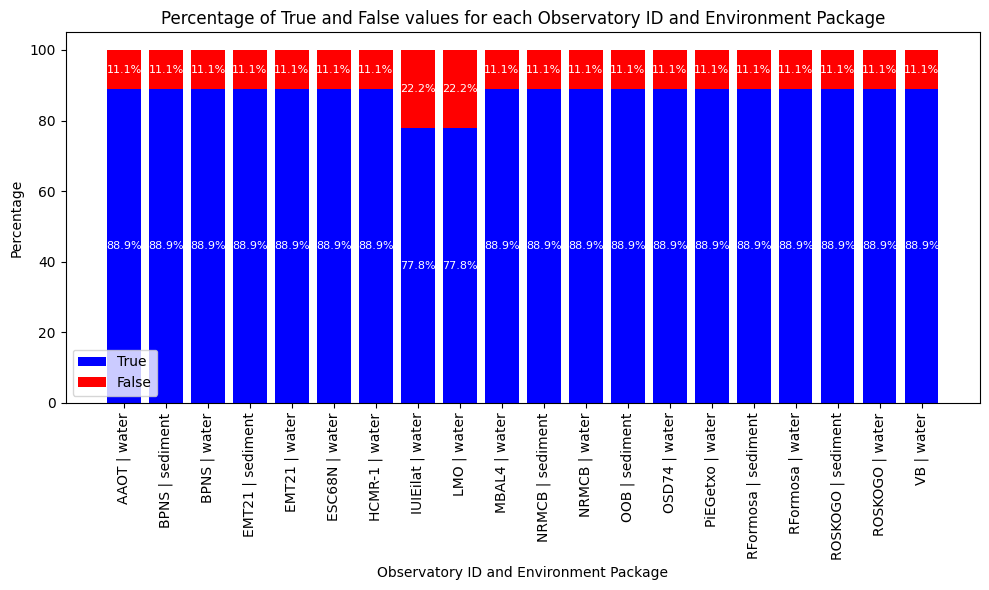

In [6]:
# For a named observatory (so I input the name), give me the number and percentage of missing information in the mandatory fields, per event (not per sample!). 
# NA is “missing information, by the way so don’t throw them out. Plot or tabulate this per mandatory field name (as given in the logsheets)

# first we get the list of mandatory fields from the logsheets
# this is present in a github csv file : https://raw.githubusercontent.com/emo-bon/observatory-profile/1dc9a426862798debd7791c75428630d37f9a818/logsheet_schema_extended.csv
# download the file and read it into a dataframe
url = "https://raw.githubusercontent.com/emo-bon/observatory-profile/1dc9a426862798debd7791c75428630d37f9a818/logsheet_schema_extended.csv"
df_mandatory_fields = pd.read_csv(url)
df_mandatory_fields = df_mandatory_fields[df_mandatory_fields['Requirement'] == 'mandatory']

# throw away the Notes , DataTypeIn , DataTypeOut , Format notes , Rxample, Define ourselves? , comments , LogsheetColumnDefinition away
df_mandatory_fields = df_mandatory_fields.drop(columns=['Notes', 'DataTypeIn', 'DataTypeOut', 'Format notes', 'Example', 'Define ourselves?', 'comments', 'LogsheetColumnDefinition'])

# some fields in the LogsheetType column have a ; in them , so we need to split them and explode the dataframe
# make sure to strip the whitespace from the LogsheetType column
df_mandatory_fields['LogsheetType'] = df_mandatory_fields['LogsheetType'].str.strip()
df_mandatory_fields['LogsheetType'] = df_mandatory_fields['LogsheetType'].str.split(';')
df_mandatory_fields = df_mandatory_fields.explode('LogsheetType')

# make a new df and give the count of each LogsheetType and the count of each mandatory field
df_mandatory_fields_count = df_mandatory_fields.groupby(['LogsheetType']).size().reset_index(name='count')

df_mandatory_fields
#df_mandatory_fields_count

# make a subset of the mandatory fields that are relevant for the observatory
df_mandatory_fields_subset = df_mandatory_fields[df_mandatory_fields['LogsheetTab'] == 'Observatory']
df_mandatory_fields_subset

# give the unique values of the LogsheetColumnTitle column
df_mandatory_fields_subset['LogsheetColumnTitle'].unique()

# manual mapping must be done to the fields in the observatory table
mapping_observatory_mandatory_fields = {
    "contact_email": "https://schema.org/contactPoint",
    "contact_name": "https://schema.org/contactPoint",
    "env_broad_biome": "https://data.emobon.embrc.eu/ns/core#broadBiome",
    "env_local": "https://data.emobon.embrc.eu/ns/core#localBiome",
    "env_package": "https://data.emobon.embrc.eu/ns/core#hasMixsPackage",
    "extra_site_info": "https://data.emobon.embrc.eu/ns/core#siteInfo",
    "geo_loc_name": "https://data.emobon.embrc.eu/ns/core#geoLocation",
    "latitude":"https://data.emobon.embrc.eu/ns/core#geoLocation", #blank node in wkt string
    "longitude":"https://data.emobon.embrc.eu/ns/core#geoLocation", #blank node in wkt string
    "loc_broad_ocean":"https://data.emobon.embrc.eu/ns/core#marineRegionName",
    "loc_broad_ocean_mrgid":"https://data.emobon.embrc.eu/ns/core#marineRegion",
    "loc_loc":"https://data.emobon.embrc.eu/ns/core#marineRegionName",
    "loc_loc_mrgid":"https://data.emobon.embrc.eu/ns/core#marineRegion",
    "loc_regional":"https://data.emobon.embrc.eu/ns/core#marineRegionName",
    "loc_regional_mrgid":"https://data.emobon.embrc.eu/ns/core#marineRegion",
    "obs_id":"https://data.emobon.embrc.eu/ns/core#observatoryId",
    "organization":"https://schema.org/contactPoint / https://schema.org/legalName",
    "organization_country":"https://schema.org/contactPoint / https://schema.org/legalName", # there is a country but for the observation , not for the organization
    "organization_edmoid":"https://schema.org/contactPoint / https://data.emobon.embrc.eu/ns/core#edmoId",
    "project_name":"http://purl.org/dc/terms/isPartOf / https://schema.org/description",
    "so_id":"https://data.emobon.embrc.eu/ns/core#observatorySampleId",
    "tot_depth_water_col":"https://data.emobon.embrc.eu/ns/core#waterColumnDepth",
    "wa_id":"https://data.emobon.embrc.eu/ns/core#observatorySampleId",
    "so_id":"https://data.emobon.embrc.eu/ns/core#observatorySampleId",
    "ARMS_unit_id":"?", #defuck
    "field_replicated_units":"?" #defuck
}

# have a giant query to find all values for checking the observatory mandatory values

sparql_observatory_mandatory_fields = '''
PREFIX core: <https://data.emobon.embrc.eu/ns/core#>
PREFIX smp: <https://data.emobon.embrc.eu/ns/sampling#>
PREFIX sosa: <http://www.w3.org/ns/sosa/>
PREFIX cvoc: <https://data.emobon.embrc.eu/ns/core_vocab#>
PREFIX prov: <http://www.w3.org/ns/prov#>
PREFIX schema: <https://schema.org/>

SELECT ?obsid ?env_package
       (COUNT(DISTINCT ?obs) AS ?obs_count)
       (COUNT(DISTINCT ?contact_email) AS ?contact_email_count)
       (COUNT(DISTINCT ?contact_name) AS ?contact_name_count)
       (COUNT(DISTINCT ?env_broad_biome) AS ?env_broad_biome_count)
       (COUNT(DISTINCT ?env_local) AS ?env_local_count)
       (COUNT(DISTINCT ?extra_site_info) AS ?extra_site_info_count)
       (COUNT(DISTINCT ?geo_loc_name) AS ?geo_loc_name_count)
       (COUNT(DISTINCT ?latitude) AS ?latitude_count)
       (COUNT(DISTINCT ?longitude) AS ?longitude_count)
       (COUNT(DISTINCT ?mr) AS ?mr_count)
       (COUNT(DISTINCT ?mrgid) AS ?mrgid_count)
       (COUNT(DISTINCT ?organization) AS ?organization_count)
       (COUNT(DISTINCT ?organization_country) AS ?organization_country_count)
       (COUNT(DISTINCT ?organization_edmoid) AS ?organization_edmoid_count)
       (COUNT(DISTINCT ?project_name) AS ?project_name_count)
       (COUNT(DISTINCT ?so_id) AS ?so_id_count)
       (COUNT(DISTINCT ?tot_depth_water_col) AS ?tot_depth_water_col_count)
       (COUNT(DISTINCT ?wa_id) AS ?wa_id_count)
WHERE { 
    ?obs a core:Observatory .
    ?obs core:observatoryId ?obsid .
    ?obs core:hasMixsPackage ?env_package .
    OPTIONAL { ?obs schema:contactPoint ?contact_email . }
    OPTIONAL { ?obs schema:contactPoint ?contact_name . }
    OPTIONAL { ?obs core:broadBiome ?env_broad_biome . }
    OPTIONAL { ?obs core:localBiome ?env_local . }
    OPTIONAL { ?obs core:siteInfo ?extra_site_info . }
    OPTIONAL { ?obs core:geoLocation ?geo_loc_name . }
    OPTIONAL { ?obs core:marineRegionName ?mr . }
    OPTIONAL { ?obs core:marineRegion ?mrgid . }
    OPTIONAL { ?obs schema:contactPoint/schema:legalName ?organization . }
    OPTIONAL { ?obs schema:contactPoint ?organization_country . }
    OPTIONAL { ?obs schema:contactPoint/core:edmoId ?organization_edmoid . }
    OPTIONAL { ?obs <http://purl.org/dc/terms/isPartOf> ?project_name . }
    OPTIONAL { ?obs core:observatorySampleId ?so_id . }
    OPTIONAL { ?obs core:waterColumnDepth ?tot_depth_water_col . }
    OPTIONAL { ?obs core:observatorySampleId ?wa_id . }
}
GROUP BY ?obsid ?env_package
'''

# Execute the modified query
result_observatory_mandatory_fields: QueryResult = GDB.query(sparql=sparql_observatory_mandatory_fields)
df_observatory_mandatory_fields: DataFrame = result_observatory_mandatory_fields.to_dataframe()
df_observatory_mandatory_fields

different_vals = {
    "mr_count": 3,
    "mrgid_count": 3
}

# for each colmunn in the dataframe that is not obsid and env_package
# for each row in the dataframe, check if the value is at least 1 , if the col name is is in different_vals take the value from the different_vals dict
# make a new dict called checked_vals and have it be the same dimentions as the df_observatory_mandatory_fields dataframe
# if the check passes then write true , else write false
checked_rows = []
for row in df_observatory_mandatory_fields.iterrows():
    checked_vals = {}
    for col in df_observatory_mandatory_fields.columns:
        if col == "obsid" or col == "env_package":
            continue
        if col in different_vals:
            if row[1][col] >= different_vals[col]:
                checked_vals[col] = True
            else:
                checked_vals[col] = False
        else:
            if row[1][col] >= 1:
                checked_vals[col] = True
            else:
                checked_vals[col] = False
    checked_rows.append(checked_vals)

df_checked_rows = pd.DataFrame(checked_rows)
df_checked_rows = df_checked_rows.astype(bool)
# add the obsid and env_package columns to the df_checked_rows dataframe
df_checked_rows['obsid'] = df_observatory_mandatory_fields['obsid']
df_checked_rows['env_package'] = df_observatory_mandatory_fields['env_package']
df_checked_rows

#make another df with obsid and env_package as index and a count of the true values in each row and false values in each row
df_checked_rows_count = df_checked_rows.copy()
df_checked_rows_count = df_checked_rows_count.set_index(['obsid', 'env_package'])
df_checked_rows_count = df_checked_rows_count.apply(pd.Series.value_counts, axis=1).fillna(0)
df_checked_rows_count = df_checked_rows_count.astype(int)
df_checked_rows_count = df_checked_rows_count.rename(columns={True: 'true', False: 'false'})
df_checked_rows_count = df_checked_rows_count.reset_index()
df_checked_rows_count = df_checked_rows_count.set_index(['obsid', 'env_package'])
df_checked_rows_count = df_checked_rows_count.groupby(['obsid', 'env_package']).sum()
df_checked_rows_count

# Calculate the percentage of true and false values
df_checked_rows_count['total'] = df_checked_rows_count['true'] + df_checked_rows_count['false']
df_checked_rows_count['true_percentage'] = (df_checked_rows_count['true'] / df_checked_rows_count['total']) * 100
df_checked_rows_count['false_percentage'] = (df_checked_rows_count['false'] / df_checked_rows_count['total']) * 100

# Make a matplotlib plot barchart of the df_checked_rows_count dataframe with percentages
fig, ax = plt.subplots(figsize=(10, 6))
index_labels = [' | '.join(map(str, idx)) for idx in df_checked_rows_count.index]  # Convert MultiIndex to strings

# Plot true percentage as blue bars
bars_true = ax.bar(index_labels, df_checked_rows_count['true_percentage'], label='True', color='blue')

# Plot false percentage as red bars
bars_false = ax.bar(index_labels, df_checked_rows_count['false_percentage'], bottom=df_checked_rows_count['true_percentage'], label='False', color='red')

# Add percentage labels to the bars
for bar, percentage in zip(bars_true, df_checked_rows_count['true_percentage']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() / 2, f'{percentage:.1f}%', ha='center', va='center', color='white', fontsize=8)

for bar, percentage, true_height in zip(bars_false, df_checked_rows_count['false_percentage'], df_checked_rows_count['true_percentage']):
    ax.text(bar.get_x() + bar.get_width() / 2, true_height + bar.get_height() / 2, f'{percentage:.1f}%', ha='center', va='center', color='white', fontsize=8)

ax.set_xlabel('Observatory ID and Environment Package')
ax.set_ylabel('Percentage')
ax.set_title('Percentage of True and False values for each Observatory ID and Environment Package')
ax.legend()
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()





In [7]:
# get the mandatory fields for the samples per event 

url = "https://raw.githubusercontent.com/emo-bon/observatory-profile/1dc9a426862798debd7791c75428630d37f9a818/logsheet_schema_extended.csv"
df_mandatory_fields = pd.read_csv(url)
df_mandatory_fields = df_mandatory_fields[df_mandatory_fields['Requirement'] == 'mandatory']

# throw away the Notes , DataTypeIn , DataTypeOut , Format notes , Rxample, Define ourselves? , comments , LogsheetColumnDefinition away
df_mandatory_fields = df_mandatory_fields.drop(columns=['Notes', 'DataTypeIn', 'DataTypeOut', 'Format notes', 'Example', 'Define ourselves?', 'comments', 'LogsheetColumnDefinition'])

# some fields in the LogsheetType column have a ; in them , so we need to split them and explode the dataframe
# make sure to strip the whitespace from the LogsheetType column
df_mandatory_fields['LogsheetType'] = df_mandatory_fields['LogsheetType'].str.strip()
df_mandatory_fields['LogsheetType'] = df_mandatory_fields['LogsheetType'].str.split(';')
df_mandatory_fields = df_mandatory_fields.explode('LogsheetType')

# make a new df and give the count of each LogsheetType and the count of each mandatory field
df_mandatory_fields_count = df_mandatory_fields.groupby(['LogsheetType']).size().reset_index(name='count')

df_mandatory_fields
#df_mandatory_fields_count

# make a subset of the mandatory fields that are relevant for the observatory
df_mandatory_fields_subset = df_mandatory_fields[df_mandatory_fields['LogsheetTab'] == 'Sampling']
# give the unique values of the LogsheetColumnTitle column
unique = df_mandatory_fields_subset['LogsheetColumnTitle'].unique()
unique

sampling_mandatory_fields = {
    'ENA_accession_number_sample':'?samplefoi/ emobon-sampling:enaSampleAccNum', 
    'arr_date_hq':'?samplefoi / prov:wasGeneratedBy / prov:wasInformedBy / prov:wasInformedBy / prov:startedAtTime',
    'arr_date_seq':'?samplefoi / prov:wasGeneratedBy / prov:startedAtTime',
    'collection_date':'?sample_event / prov:startedAtTime',
    'collection_date_arms':'', # ARMS ?
    'depth':'?samplefoi / emobon-sampling:minSampleDepth',
    'env_material':'?samplefoi / emobon-sampling:environmentMaterial',
    'investigation_type':'?samplefoi / emobon-sampling:investigationType',
    'long_store':'?samplefoi / emobon-sampling:longStorage',
    'membr_cut':'?samplefoi / emobon-sampling:membrCut',
    'samp_collect_device':'?sample_event / sosa:madeBySampler',
    'samp_description':'?samplefoi / dct:description',
    'samp_size_mass':'?samplefoi / emobon-sampling:hasSampleSize',
    'samp_mat_process':'?sample_event / sosa:usedProcedure / rdfs:label',
    'samp_mat_process_dev':'?sample_event / sosa:usedProcedure / rdfs:comment',
    'samp_store_loc':'?samplefoi / prov:wasGeneratedBy / prov:wasInformedBy / prov:wasInformedBy / prov:wasInformedBy / prov:wasInformedBy / emobon-sampling:storageLoc',
    'samp_store_temp':'?samplefoi / prov:wasGeneratedBy / prov:wasInformedBy / prov:wasInformedBy / prov:wasInformedBy / prov:wasInformedBy / emobon-sampling:storageTemp',
    'samp_size_vol':'?samplefoi / emobon-sampling:hasSampleSize',
    'sampl_person':'?samplefoi / prov:wasAssociatedWith / schema:name',
    'sampling_event':'?samplefoi / sosa:isResultOf',
    'ship_date':'?samplefoi / prov:wasGeneratedBy / prov:wasInformedBy / prov:wasInformedBy / prov:wasInformedBy / prov:startedAtTime',
    'ship_date_seq':'?samplefoi / prov:wasGeneratedBy / prov:wasInformedBy / prov:startedAtTime',
    'size_frac_low':'?samplefoi / emobon-sampling:lowerFilterSize',
    'size_frac_up':'?samplefoi / emobon-sampling:upperFilterSize',
    'size_frac':'?samplefoi / emobon-sampling:filterSizeRange',
    'store_person':'?samplefoi / prov:wasAssociatedWith / schema:name', 
    'store_temp_hq':'?samplefoi / prov:wasGeneratedBy / prov:wasInformedBy / prov:wasInformedBy / emobon-sampling:storageTemp',
    'tax_id':'?samplefoi / emobon-sampling:taxonomicID',
    'time_fi':'?samplefoi / emobon-sampling:filtrationTime',
    'failure':'?samplefoi  emobon-sampling:failure',
    'scientific_name':'?samplefoi / emobon-sampling:taxonomicName', 
    'comm_samp':'?samplefoi / emobon-sampling:bioCommunity',
    'source_mat_id_orig':'?samplefoi / emobon-sampling:origEmobonId',
    'samp_store_date':'?samplefoi / prov:wasGeneratedBy / prov:wasInformedBy / prov:wasInformedBy / prov:wasInformedBy / prov:wasInformedBy / prov:startedAtTime ',
    'replicate':'?samplefoi / emobon-sampling:sampleReplicate',
    'failure_comment':'?samplefoi / emobon-sampling:failureComment',
    'deployment_date':'', # ARMS ? not included in any of the template files 
    'samp_fraction':'', # ARMS ? not included in any of the template files 
    'preservative':'', # ARMS ? not included in any of the template files 
    'crate_cover':'', # ARMS ? not included in any of the template files 
    'size_filter':'', # ARMS ? not included in any of the template files 
    'images_in_PlutoF':'' # ARMS ? not included in any of the template files 
}

# comments on fields:
# store_person and sample_person lead to the same path in the triplestore
# since both are required there should be at least 2 of them in the results when there is a count query for the fields
# however if the store person and the sample person are the same person this would also be valid and would lead to a count of 1
# so there is no knowing which one would be missing or if this would be a false negative


# big query to get all the values for the sampling mandatory fields
query_sampling_mandatory_fields = '''
PREFIX core: <https://data.emobon.embrc.eu/ns/core#>
PREFIX emobon-sampling: <https://data.emobon.embrc.eu/ns/sampling#>
PREFIX sosa: <http://www.w3.org/ns/sosa/>
PREFIX prov: <http://www.w3.org/ns/prov#>
PREFIX dct: <http://purl.org/dc/terms/>
PREFIX schema: <https://schema.org/>
SELECT ?sample_event ?obs
       (COUNT(DISTINCT ?ENA_accession_number_sample) AS ?ENA_accession_number_sample_count)
       (COUNT(DISTINCT ?arr_date_hq) AS ?arr_date_hq_count)
       (COUNT(DISTINCT ?arr_date_seq) AS ?arr_date_seq_count)
       (COUNT(DISTINCT ?collection_date) AS ?collection_date_count)
       (COUNT(DISTINCT ?depth) AS ?depth_count)
       (COUNT(DISTINCT ?env_material) AS ?env_material_count)
       (COUNT(DISTINCT ?investigation_type) AS ?investigation_type_count)
       (COUNT(DISTINCT ?long_store) AS ?long_store_count)
       (COUNT(DISTINCT ?membr_cut) AS ?membr_cut_count)
       (COUNT(DISTINCT ?samp_collect_device) AS ?samp_collect_device_count)
       (COUNT(DISTINCT ?samp_description) AS ?samp_description_count)
       (COUNT(DISTINCT ?samp_size_mass) AS ?samp_size_mass_count)
       (COUNT(DISTINCT ?samp_mat_process) AS ?samp_mat_process_count)
       (COUNT(DISTINCT ?samp_mat_process_dev) AS ?samp_mat_process_dev_count)
       (COUNT(DISTINCT ?samp_store_loc) AS ?samp_store_loc_count)
       (COUNT(DISTINCT ?samp_store_temp) AS ?samp_store_temp_count)
       (COUNT(DISTINCT ?samp_size_vol) AS ?samp_size_vol_count)
       (COUNT(DISTINCT ?sampl_person) AS ?sampl_person_count)
       (COUNT(DISTINCT ?sampling_event) AS ?sampling_event_count)
       (COUNT(DISTINCT ?ship_date) AS ?ship_date_count)
       (COUNT(DISTINCT ?ship_date_seq) AS ?ship_date_seq_count)
       (COUNT(DISTINCT ?size_frac_low) AS ?size_frac_low_count)
       (COUNT(DISTINCT ?size_frac_up) AS ?size_frac_up_count)
       (COUNT(DISTINCT ?size_frac) AS ?size_frac_count)
       (COUNT(DISTINCT ?store_person) AS ?store_person_count)
       (COUNT(DISTINCT ?store_temp_hq) AS ?store_temp_hq_count)
       (COUNT(DISTINCT ?tax_id) AS ?tax_id_count)
       (COUNT(DISTINCT ?time_fi) AS ?time_fi_count)
       (COUNT(DISTINCT ?failure) AS ?failure_count)
       (COUNT(DISTINCT ?scientific_name) AS ?scientific_name_count)
       (COUNT(DISTINCT ?comm_samp) AS ?comm_samp_count)
       (COUNT(DISTINCT ?source_mat_id_orig) AS ?source_mat_id_orig_count)
       (COUNT(DISTINCT ?samp_store_date) AS ?samp_store_date_count)
       (COUNT(DISTINCT ?replicate) AS ?replicate_count)
       (COUNT(DISTINCT ?failure_comment) AS ?failure_comment_count)
WHERE { 
    ?s a sosa:Observation .
    ?s sosa:hasFeatureOfInterest ?samplefoi .
    ?samplefoi sosa:isResultOf ?sample_event .
    ?sample_event emobon-sampling:linkedToObservatory ?obs .

    OPTIONAL { ?samplefoi emobon-sampling:enaSampleAccNum ?ENA_accession_number_sample . }
    OPTIONAL { ?samplefoi prov:wasGeneratedBy/prov:wasInformedBy/prov:wasInformedBy/prov:startedAtTime ?arr_date_hq . }
    OPTIONAL { ?samplefoi prov:wasGeneratedBy/prov:startedAtTime ?arr_date_seq . }
    OPTIONAL { ?sample_event prov:startedAtTime ?collection_date . }
    OPTIONAL { ?samplefoi emobon-sampling:minSampleDepth ?depth . }
    OPTIONAL { ?samplefoi emobon-sampling:environmentMaterial ?env_material . }
    OPTIONAL { ?samplefoi emobon-sampling:investigationType ?investigation_type . }
    OPTIONAL { ?samplefoi emobon-sampling:longStorage ?long_store . }
    OPTIONAL { ?samplefoi emobon-sampling:membrCut ?membr_cut . }
    OPTIONAL { ?sample_event sosa:madeBySampler ?samp_collect_device . }
    OPTIONAL { ?samplefoi dct:description ?samp_description . }
    OPTIONAL { ?samplefoi emobon-sampling:hasSampleSize ?samp_size_mass . }
    OPTIONAL { ?sample_event sosa:usedProcedure/rdfs:label ?samp_mat_process . }
    OPTIONAL { ?sample_event sosa:usedProcedure/rdfs:comment ?samp_mat_process_dev . }
    OPTIONAL { ?samplefoi prov:wasGeneratedBy/prov:wasInformedBy/prov:wasInformedBy/prov:wasInformedBy/prov:wasInformedBy/emobon-sampling:storageLoc ?samp_store_loc . }
    OPTIONAL { ?samplefoi prov:wasGeneratedBy/prov:wasInformedBy/prov:wasInformedBy/prov:wasInformedBy/prov:wasInformedBy/emobon-sampling:storageTemp ?samp_store_temp . }
    OPTIONAL { ?samplefoi emobon-sampling:hasSampleSize ?samp_size_vol . }
    OPTIONAL { ?samplefoi prov:wasAssociatedWith/schema:name ?sampl_person . }
    OPTIONAL { ?samplefoi sosa:isResultOf ?sampling_event . }
    OPTIONAL { ?samplefoi prov:wasGeneratedBy/prov:wasInformedBy/prov:wasInformedBy/prov:wasInformedBy/prov:startedAtTime ?ship_date . }
    OPTIONAL { ?samplefoi prov:wasGeneratedBy/prov:wasInformedBy/prov:startedAtTime ?ship_date_seq . }
    OPTIONAL { ?samplefoi emobon-sampling:lowerFilterSize ?size_frac_low . }
    OPTIONAL { ?samplefoi emobon-sampling:upperFilterSize ?size_frac_up . }
    OPTIONAL { ?samplefoi emobon-sampling:filterSizeRange ?size_frac . }
    OPTIONAL { ?samplefoi prov:wasAssociatedWith/schema:name ?store_person . }
    OPTIONAL { ?samplefoi prov:wasGeneratedBy/prov:wasInformedBy/prov:wasInformedBy/emobon-sampling:storageTemp ?store_temp_hq . }
    OPTIONAL { ?samplefoi emobon-sampling:taxonomicID ?tax_id . }
    OPTIONAL { ?samplefoi emobon-sampling:filtrationTime ?time_fi . }
    OPTIONAL { ?samplefoi emobon-sampling:failure ?failure . }
    OPTIONAL { ?samplefoi emobon-sampling:taxonomicName ?scientific_name . }
    OPTIONAL { ?samplefoi emobon-sampling:bioCommunity ?comm_samp . }
    OPTIONAL { ?samplefoi emobon-sampling:origEmobonId ?source_mat_id_orig . }
    OPTIONAL { ?samplefoi prov:wasGeneratedBy/prov:wasInformedBy/prov:wasInformedBy/prov:wasInformedBy/prov:wasInformedBy/prov:startedAtTime ?samp_store_date . }
    OPTIONAL { ?samplefoi emobon-sampling:sampleReplicate ?replicate . }
    OPTIONAL { ?samplefoi emobon-sampling:failureComment ?failure_comment . }
}
GROUP BY ?sample_event ?obs
ORDER BY ?obs
'''

# Execute the modified query
result_sampling_mandatory_fields: QueryResult = GDB.query(sparql=query_sampling_mandatory_fields)
df_sampling_mandatory_fields: DataFrame = result_sampling_mandatory_fields.to_dataframe()
df_sampling_mandatory_fields

different_vals = {
    "store_person": 2, # can give false negative if the store person and sample person are the same
    "sampl_person": 2 # can give false negative if the store person and sample person are the same
}

checked_rows = []
for row in df_sampling_mandatory_fields.iterrows():
    checked_vals = {}
    for col in df_sampling_mandatory_fields.columns:
        if col == "sample_event" or col == "obs":
            continue
        if col in different_vals:
            if row[1][col] >= different_vals[col]:
                checked_vals[col] = True
            else:
                checked_vals[col] = False
        else:
            if row[1][col] >= 1:
                checked_vals[col] = True
            else:
                checked_vals[col] = False
    checked_rows.append(checked_vals)

df_checked_rows = pd.DataFrame(checked_rows)
df_checked_rows = df_checked_rows.astype(bool)
df_checked_rows['sample_event'] = df_sampling_mandatory_fields['sample_event']
df_checked_rows['obs'] = df_sampling_mandatory_fields['obs']
df_checked_rows

df_checked_rows_count = df_checked_rows.copy()
df_checked_rows_count = df_checked_rows_count.set_index(['sample_event', 'obs'])
df_checked_rows_count = df_checked_rows_count.apply(pd.Series.value_counts, axis=1).fillna(0)
df_checked_rows_count = df_checked_rows_count.astype(int)
df_checked_rows_count = df_checked_rows_count.rename(columns={True: 'true', False: 'false'})
df_checked_rows_count = df_checked_rows_count.reset_index()
df_checked_rows_count = df_checked_rows_count.set_index(['sample_event','obs'])
df_checked_rows_count = df_checked_rows_count.groupby(['sample_event','obs']).sum()
df_checked_rows_count

# Calculate the percentage of true and false values
df_checked_rows_count['total'] = df_checked_rows_count['true'] + df_checked_rows_count['false']
df_checked_rows_count['true_percentage'] = (df_checked_rows_count['true'] / df_checked_rows_count['total']) * 100
df_checked_rows_count['false_percentage'] = (df_checked_rows_count['false'] / df_checked_rows_count['total']) * 100

# Sort the events by the percentage of missing values (false percentage) in ascending order
df_checked_rows_count = df_checked_rows_count.sort_values(by='false_percentage', ascending=True)
df_checked_rows_count

# interactive table where user can choose between observatories to see what specific fields are missing
# df to use is df_checked_rows 
# field for choosing is obs 
# filter on field chosen and then display the table with the missing values
fields_to_choose = df_checked_rows['obs'].unique()
# Create a dropdown widget for selecting an observatory
obs_dropdown = widgets.Dropdown(
    options=fields_to_choose,
    description='Observatory:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='50%')
)

# Function to filter and display the table and update the barchart based on the selected observatory
def filter_and_plot(selected_obs):
    # Filter the DataFrame based on the selected observatory
    filtered_df = df_checked_rows[df_checked_rows['obs'] == selected_obs]
    
    # Create a new DataFrame that is a copy of the filtered DataFrame
    filtered_df_copy = filtered_df.copy()

    # Set the index to the sampling_event column
    filtered_df_copy.set_index('sample_event', inplace=True)

    # Create a new column "missing values" by finding all column names with False values in each row
    filtered_df_copy['missing values'] = filtered_df_copy.apply(
        lambda row: ' , '.join(row.index[row == False]), axis=1
    )
    
    filtered_df_copy['count_missing_values'] = filtered_df_copy.apply(
        lambda row: len(row.index[row == False]), axis=1
    )
    
    filtered_df_copy['total_values'] = filtered_df_copy.apply(
        lambda row: len(row.index), axis=1
    )
    filtered_df_copy['percentage_missing_values'] = (filtered_df_copy['count_missing_values'] / filtered_df_copy['total_values']) * 100

    # Reset the index and only display the sampling_event and missing values columns
    filtered_df_copy.reset_index(inplace=True)
    filtered_df_copy = filtered_df_copy[['sample_event', 'missing values', 'count_missing_values', 'percentage_missing_values']]

    display(filtered_df_copy)

    if filtered_df_copy.empty:
        print("No missing values found for the selected observatory.")
    else:
        # Create a barchart plot for sampling events with missing values percentage
        fig, ax = plt.subplots(figsize=(10, 8))

        # Sort the data by percentage of missing values
        filtered_df_sorted = filtered_df_copy.sort_values(by='percentage_missing_values', ascending=False)

        # Extract the last 20 characters of the sampling event names for the y-axis
        event_labels = [f"...{str(idx)[-20:]}" for idx in filtered_df_sorted['sample_event']]

        # Plot the bar chart
        ax.barh(event_labels, filtered_df_sorted['percentage_missing_values'], color='red', label='Missing Values (%)')

        # Add labels and title
        ax.set_xlabel('Percentage of Missing Values')
        ax.set_ylabel('Sampling Events (last 20 characters)')
        ax.set_title(f'Percentage of Missing Values for Observatory: {selected_obs}')
        ax.invert_yaxis()  # Invert y-axis to have the highest percentage at the top
        ax.grid(axis='x', linestyle='--', alpha=0.7)
        ax.legend()

        plt.tight_layout()
        plt.show()

# Create an interactive output
output = widgets.interactive_output(filter_and_plot, {'selected_obs': obs_dropdown})

# Display the dropdown and the output
display(obs_dropdown, output)


Dropdown(description='Observatory:', layout=Layout(width='50%'), options=('http://data.emobon.embrc.eu/observa…

Output()

In [8]:
# get the mandatory fields for each measurement
url = "https://raw.githubusercontent.com/emo-bon/observatory-profile/1dc9a426862798debd7791c75428630d37f9a818/logsheet_schema_extended.csv"
df_mandatory_fields = pd.read_csv(url)
df_mandatory_fields = df_mandatory_fields[df_mandatory_fields['Requirement'] == 'mandatory']

# throw away the Notes , DataTypeIn , DataTypeOut , Format notes , Rxample, Define ourselves? , comments , LogsheetColumnDefinition away
df_mandatory_fields = df_mandatory_fields.drop(columns=['Notes', 'DataTypeIn', 'DataTypeOut', 'Format notes', 'Example', 'Define ourselves?', 'comments', 'LogsheetColumnDefinition'])

# some fields in the LogsheetType column have a ; in them , so we need to split them and explode the dataframe
# make sure to strip the whitespace from the LogsheetType column
df_mandatory_fields['LogsheetType'] = df_mandatory_fields['LogsheetType'].str.strip()
df_mandatory_fields['LogsheetType'] = df_mandatory_fields['LogsheetType'].str.split(';')
df_mandatory_fields = df_mandatory_fields.explode('LogsheetType')

# make a new df and give the count of each LogsheetType and the count of each mandatory field
df_mandatory_fields_count = df_mandatory_fields.groupby(['LogsheetType']).size().reset_index(name='count')

df_mandatory_fields
#df_mandatory_fields_count

# make a subset of the mandatory fields that are relevant for the observatory
df_mandatory_fields_subset = df_mandatory_fields[df_mandatory_fields['LogsheetTab'] == 'Measured']
# give the unique values of the LogsheetColumnTitle column
unique = df_mandatory_fields_subset['LogsheetColumnTitle'].unique()
print(unique)

# query to get all observations with their respected sample and sampling event 
query = '''
PREFIX core: <https://data.emobon.embrc.eu/ns/core#>
PREFIX emobon-sampling: <https://data.emobon.embrc.eu/ns/sampling#>
PREFIX sosa: <http://www.w3.org/ns/sosa/>
PREFIX prov: <http://www.w3.org/ns/prov#>
PREFIX dct: <http://purl.org/dc/terms/>
PREFIX schema: <https://schema.org/>
select ?sample_event ?samplefoi ?observation ?measurement_technique where { 
	?observation a sosa:Observation .
    #?s sosa:hasFeatureOfInterest/sosa:isResultOf/smp:linkedToObservatory ?obs .
    ?observation sosa:hasFeatureOfInterest ?samplefoi .
    ?samplefoi sosa:isResultOf ?sample_event .
    ?observation schema:measurementTechnique ?measurement_technique .
}
'''

# Execute the modified query
result: QueryResult = GDB.query(sparql=query)
df: DataFrame = result.to_dataframe()

# get the unique sampling events 
df['sample_event'].unique()

# make a subset of all the unique mandatory fields that do not contain method in the name
non_method_fields = df_mandatory_fields_subset[~df_mandatory_fields_subset['LogsheetColumnTitle'].str.contains('method', case=False)]

# Create a dropdown widget for selecting a sample_event
sample_event_dropdown = widgets.Dropdown(
    options=df['sample_event'].unique(),
    description='Sample Event:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='50%')
)
'''
# Create a dropdown widget for selecting a field from df_mandatory_fields_subset
field_dropdown = widgets.Dropdown(
    options=non_method_fields['LogsheetColumnTitle'].unique(),
    description='Field:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='50%')
)
'''

# Function to filter the DataFrame and add the "present" column
def filter_and_check(sample_event):
    
    # make a variable that contains the unique samplefoi for the selected sample_event
    samplefoi = df[df['sample_event'] == sample_event]['samplefoi'].unique()
    
    # Filter the DataFrame based on the selected sample_event
    filtered_df = df[df['sample_event'] == sample_event]
    
    results = []
    
    for field in unique:
        if 'method' in field:
            field_without_method = field.replace('_method', '')
            filtered_df_field = filtered_df[filtered_df['observation'].str.contains(field_without_method, case=False, na=False)]
            # filter again to only include the rows for which the measurements column is not empty
            # filtered_df_field = filtered_df_field[filtered_df_field['measurement_technique'].notna()]
        else:
            # filter df to only include the selected field in the string of the observation
            filtered_df_field = filtered_df[filtered_df['observation'].str.contains(field, case=False, na=False)]
    
        # get the unique samplefoi for the selected sample_event
        samplefoi_f = filtered_df_field['samplefoi'].unique()
        
        print(f"{field}:{len(samplefoi_f)}/{len(samplefoi)}")
        results.append((field, len(samplefoi_f), len(samplefoi)))
    
    
    # Set the index of the filtered DataFrame to sample_event
    filtered_df.set_index('sample_event', inplace=True)
    
    # Create a DataFrame from the results
    results_df = pd.DataFrame(results, columns=['Field', 'Present Count', 'Total Count'])

    # Calculate the percentage of samples with the field present
    results_df['Present Percentage'] = (results_df['Present Count'] / results_df['Total Count']) * 100
    results_df['Missing Percentage'] = 100 - results_df['Present Percentage']

    # Filter out fields based on the event name
    if "sediment" in sample_event.lower():
        results_df = results_df[~results_df['Field'].str.contains('sea', case=False)]
    elif "water" in sample_event.lower():
        results_df = results_df[~results_df['Field'].str.contains('sediment', case=False)]

    # Plot the results as a barchart
    fig, ax = plt.subplots(figsize=(12, 8))

    # Plot present percentage as blue bars
    bars_present = ax.bar(results_df['Field'], results_df['Present Percentage'], label='Present', color='blue')

    # Plot missing percentage as red bars
    bars_missing = ax.bar(results_df['Field'], results_df['Missing Percentage'], bottom=results_df['Present Percentage'], label='Missing', color='red')

    # Add percentage labels to the bars
    for bar, percentage in zip(bars_present, results_df['Present Percentage']):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() / 2, f'{percentage:.1f}%', ha='center', va='center', color='white', fontsize=8)

    for bar, percentage, present_height in zip(bars_missing, results_df['Missing Percentage'], results_df['Present Percentage']):
        ax.text(bar.get_x() + bar.get_width() / 2, present_height + bar.get_height() / 2, f'{percentage:.1f}%', ha='center', va='center', color='white', fontsize=8)

    # Customize the plot
    ax.set_xlabel('Field')
    ax.set_ylabel('Percentage')
    ax.set_title(f'Percentage of Samples with Fields Present or Missing for Sample Event: {sample_event}')
    ax.legend()
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()
    
    # Display the filtered DataFrame without the index
    display(filtered_df.reset_index(drop=True))

# Create an interactive output
output = widgets.interactive_output(filter_and_check, {'sample_event': sample_event_dropdown})

# Display the dropdowns and the output
display(sample_event_dropdown,  output)


['ph' 'ph_method' 'redox_potential' 'sea_subsurf_salinity'
 'sea_subsurf_salinity_method' 'sea_subsurf_temp'
 'sea_subsurf_temp_method' 'sea_surf_temp' 'sea_surf_temp_method'
 'sediment_temp' 'sediment_temp_method']


Dropdown(description='Sample Event:', layout=Layout(width='50%'), options=('http://data.emobon.embrc.eu/observ…

Output()

In [9]:
# For the mandatory measurements, give me the mean and mean deviation, as well as max and min values, for a named observatory (so I input the name), summed over all sampling events and over all water events separately (plots could be side-by-side). Give me this following the BODC names but then also output a list of BODC vs googlesheet names so I can read that off. Throw out the NAs here

url = "https://raw.githubusercontent.com/emo-bon/observatory-profile/1dc9a426862798debd7791c75428630d37f9a818/logsheet_schema_extended.csv"
df_mandatory_fields = pd.read_csv(url)
df_mandatory_fields = df_mandatory_fields[df_mandatory_fields['Requirement'] == 'mandatory']

# throw away the Notes , DataTypeIn , DataTypeOut , Format notes , Rxample, Define ourselves? , comments , LogsheetColumnDefinition away
df_mandatory_fields = df_mandatory_fields.drop(columns=['Notes', 'DataTypeIn', 'DataTypeOut', 'Format notes', 'Example', 'Define ourselves?', 'comments', 'LogsheetColumnDefinition'])

# some fields in the LogsheetType column have a ; in them , so we need to split them and explode the dataframe
# make sure to strip the whitespace from the LogsheetType column
df_mandatory_fields['LogsheetType'] = df_mandatory_fields['LogsheetType'].str.strip()
df_mandatory_fields['LogsheetType'] = df_mandatory_fields['LogsheetType'].str.split(';')
df_mandatory_fields = df_mandatory_fields.explode('LogsheetType')

# make a new df and give the count of each LogsheetType and the count of each mandatory field
df_mandatory_fields_count = df_mandatory_fields.groupby(['LogsheetType']).size().reset_index(name='count')

df_mandatory_fields
#df_mandatory_fields_count

# make a subset of the mandatory fields that are relevant for the observatory
df_mandatory_fields_subset = df_mandatory_fields[df_mandatory_fields['LogsheetTab'] == 'Measured']
# give the unique values of the LogsheetColumnTitle column
unique = df_mandatory_fields_subset['LogsheetColumnTitle'].unique()
print(unique)

# query to get all observations with their respected sample and sampling event 
query = '''
PREFIX core: <https://data.emobon.embrc.eu/ns/core#>
PREFIX emobon-sampling: <https://data.emobon.embrc.eu/ns/sampling#>
PREFIX sosa: <http://www.w3.org/ns/sosa/>
PREFIX prov: <http://www.w3.org/ns/prov#>
PREFIX dct: <http://purl.org/dc/terms/>
PREFIX schema: <https://schema.org/>
select ?observatory ?sample_event ?samplefoi ?observation ?value ?unit where { 
	?observation a sosa:Observation .
    #?s sosa:hasFeatureOfInterest/sosa:isResultOf/smp:linkedToObservatory ?obs .
    ?observation sosa:hasFeatureOfInterest ?samplefoi .
    ?observation sosa:hasResult ?result .
    ?result <http://qudt.org/schema/qudt/numericValue> ?value .
    ?result <http://qudt.org/schema/qudt/unit> ?unit .
    ?samplefoi sosa:isResultOf ?sample_event .
    ?sample_event emobon-sampling:linkedToObservatory ?observatory .
}
'''

# Execute the modified query
result: QueryResult = GDB.query(sparql=query)
df: DataFrame = result.to_dataframe()

# get the unique observatories
df['observatory'].unique()

# make a subset of all the unique mandatory fields that do not contain method in the name
non_method_fields = df_mandatory_fields_subset[~df_mandatory_fields_subset['LogsheetColumnTitle'].str.contains('method', case=False)]
# Create a dropdown widget for selecting a sample_event
sample_event_dropdown = widgets.Dropdown(
    options=df['observatory'].unique(),
    description='Observatory:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='50%')
)

# Function to filter and display the DataFrame based on the selected observatory
def filter_observatory(selected_observatory):
    # Filter the DataFrame based on the selected observatory
    filtered_df = df[df['observatory'] == selected_observatory]
    all_values = []
    
    for field in non_method_fields['LogsheetColumnTitle'].unique():
        filtered_df_field = filtered_df[filtered_df['observation'].str.contains(field, case=False, na=False)]
        #make a new list with all the values from the value field
        values = filtered_df_field['value'].tolist()
        try:
            # calculate the mean and standard deviation of the values
            mean = np.nanmean(values)
            std = np.nanstd(values)
            min_val = np.nanmin(values)
            max_val = np.nanmax(values)
            print(f"Field: {field}, Mean: {mean}, Std: {std}, Min: {min_val}, Max: {max_val}")
            all_values.append((field, mean, std, min_val, max_val))
        except ValueError:
            print(f"Field: {field}, could not calculate statistics due to missing or invalid values.")
    
    
    # Create a DataFrame from all_values for plotting
    stats_df = pd.DataFrame(all_values, columns=['Field', 'Mean', 'Std', 'Min', 'Max'])

    # Create a separate subplot for each field
    num_fields = len(stats_df['Field'])
    fig, axes = plt.subplots(nrows=num_fields, ncols=1, figsize=(12, 4 * num_fields), sharex=False)

    if num_fields == 1:
        axes = [axes]  # Ensure axes is iterable when there's only one subplot

    for ax, field in zip(axes, stats_df['Field']):
        field_values = filtered_df[filtered_df['observation'].str.contains(field, case=False, na=False)]['value'].dropna()
        ax.boxplot(field_values, vert=False)
        ax.set_xlabel('Values', fontsize=10)
        ax.set_ylabel(field, fontsize=10)

        # Get statistics for the field
        field_stats = stats_df[stats_df['Field'] == field].iloc[0]
        mean = round(field_stats['Mean'], 2)
        std = round(field_stats['Std'], 2)
        min_val = round(field_stats['Min'], 2)
        max_val = round(field_stats['Max'], 2)

        # Annotate the plot with statistics
        ax.text(0.95, 0.95, f"Mean: {mean}\nStd: {std}\nMin: {min_val}\nMax: {max_val}",
                transform=ax.transAxes, fontsize=10, verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle="round", facecolor="white", alpha=0.5))

    # Adjust layout for better readability
    plt.tight_layout()
    plt.show()
    
    display(filtered_df)

# Create an interactive output
output = widgets.interactive_output(filter_observatory, {'selected_observatory': sample_event_dropdown})

# Display the dropdown and the output
display(sample_event_dropdown, output)


['ph' 'ph_method' 'redox_potential' 'sea_subsurf_salinity'
 'sea_subsurf_salinity_method' 'sea_subsurf_temp'
 'sea_subsurf_temp_method' 'sea_surf_temp' 'sea_surf_temp_method'
 'sediment_temp' 'sediment_temp_method']


Dropdown(description='Observatory:', layout=Layout(width='50%'), options=('http://data.emobon.embrc.eu/observa…

Output()

In [10]:
# 6: Over all the observatories, list the samp_collect_devices used and the number of events (not samples) each was used for (I want to see how many different ones there are). Here you can throw out the NAs before reporting.
# --> matched to query e (collect_device_usage)

query = '''
PREFIX core: <https://data.emobon.embrc.eu/ns/core#>
PREFIX emobon-sampling: <https://data.emobon.embrc.eu/ns/sampling#>
PREFIX sosa: <http://www.w3.org/ns/sosa/>
PREFIX prov: <http://www.w3.org/ns/prov#>
PREFIX dct: <http://purl.org/dc/terms/>
PREFIX schema: <https://schema.org/>
select ?sample_event ?samplefoi ?observation ?measurement_technique ?samp_collect_device where { 
	?observation a sosa:Observation .
    #?s sosa:hasFeatureOfInterest/sosa:isResultOf/smp:linkedToObservatory ?obs .
    ?observation sosa:hasFeatureOfInterest ?samplefoi .
    ?samplefoi sosa:isResultOf ?sample_event .
    ?sample_event sosa:madeBySampler ?samp_collect_device .
    ?observation schema:measurementTechnique ?measurement_technique .
}
ORDER BY ?samp_collect_device
'''

# Execute the modified query
result: QueryResult = GDB.query(sparql=query)
df: DataFrame = result.to_dataframe()
df
# Modify the query to count the sampling events per sampling collection device
query_count_devices = '''
PREFIX core: <https://data.emobon.embrc.eu/ns/core#>
PREFIX emobon-sampling: <https://data.emobon.embrc.eu/ns/sampling#>
PREFIX sosa: <http://www.w3.org/ns/sosa/>
PREFIX prov: <http://www.w3.org/ns/prov>
PREFIX dct: <http://purl.org/dc/terms/>
PREFIX schema: <https://schema.org/>
SELECT ?samp_collect_device (COUNT(DISTINCT ?sample_event) AS ?event_count)
WHERE { 
    ?observation a sosa:Observation .
    ?observation sosa:hasFeatureOfInterest ?samplefoi .
    ?samplefoi sosa:isResultOf ?sample_event .
    ?sample_event sosa:madeBySampler ?samp_collect_device .
}
GROUP BY ?samp_collect_device
ORDER BY DESC(?event_count)
'''

# Execute the modified query
result_count_devices: QueryResult = GDB.query(sparql=query_count_devices)
df_count_devices: DataFrame = result_count_devices.to_dataframe()

# Display the result
df_count_devices

# Create a dropdown widget for selecting a sampling collection device
device_dropdown = widgets.Dropdown(
    options=df_count_devices['samp_collect_device'].unique(),
    description='Device:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='50%')
)

# Function to filter and display the sampling events based on the selected device
def filter_sampling_events(selected_device):
    # Query to get sampling events for the selected device
    query_sampling_events = f'''
    PREFIX core: <https://data.emobon.embrc.eu/ns/core#>
    PREFIX emobon-sampling: <https://data.emobon.embrc.eu/ns/sampling#>
    PREFIX sosa: <http://www.w3.org/ns/sosa/>
    PREFIX prov: <http://www.w3.org/ns/prov#>
    PREFIX dct: <http://purl.org/dc/terms/>
    PREFIX schema: <https://schema.org/>
    SELECT DISTINCT ?sample_event
    WHERE {{
        ?observation a sosa:Observation .
        ?observation sosa:hasFeatureOfInterest ?samplefoi .
        ?samplefoi sosa:isResultOf ?sample_event .
        ?sample_event sosa:madeBySampler "{selected_device}" .
    }}
    ORDER BY ?sample_event
    '''
    # Execute the query
    result_sampling_events: QueryResult = GDB.query(sparql=query_sampling_events)
    df_sampling_events: DataFrame = result_sampling_events.to_dataframe()

    # Display the sampling events
    if not df_sampling_events.empty:
        display(df_sampling_events)
    else:
        print(f"No sampling events found for the device: {selected_device}")

# Create an interactive output
output_sampling_events = widgets.interactive_output(filter_sampling_events, {'selected_device': device_dropdown})

# Display the dropdown and the output
display(device_dropdown, output_sampling_events)

Dropdown(description='Device:', layout=Layout(width='50%'), options=('Niskin', 'PVC sediment corer', 'Bucket',…

Output()

In [11]:
# - 7: For each observatory, how many samples for water and for sediment separately have been shipped to HQ

query = '''
PREFIX core: <https://data.emobon.embrc.eu/ns/core#>
PREFIX emobon-sampling: <https://data.emobon.embrc.eu/ns/sampling#>
PREFIX sosa: <http://www.w3.org/ns/sosa/>
PREFIX prov: <http://www.w3.org/ns/prov#>
PREFIX dct: <http://purl.org/dc/terms/>
PREFIX schema: <https://schema.org/>
select ?obs ?samplefoi ?arr_date_hq where { 
	?observation a sosa:Observation .
    ?observation sosa:hasFeatureOfInterest ?samplefoi .
    ?samplefoi sosa:isResultOf ?sample_event .
    ?samplefoi prov:wasGeneratedBy/prov:wasInformedBy/prov:wasInformedBy/prov:startedAtTime ?arr_date_hq .
    ?sample_event emobon-sampling:linkedToObservatory ?obs .
}
'''
# Execute the modified query
result: QueryResult = GDB.query(sparql=query)
df: DataFrame = result.to_dataframe()
df

# Modify the query to count the unique samples per observatory
query_count_samples = '''
PREFIX core: <https://data.emobon.embrc.eu/ns/core#>
PREFIX emobon-sampling: <https://data.emobon.embrc.eu/ns/sampling#>
PREFIX sosa: <http://www.w3.org/ns/sosa/>
PREFIX prov: <http://www.w3.org/ns/prov#>
PREFIX dct: <http://purl.org/dc/terms/>
PREFIX schema: <https://schema.org/>
SELECT ?obs (COUNT(DISTINCT ?samplefoi) AS ?unique_sample_count)
WHERE { 
    ?observation a sosa:Observation .
    ?observation sosa:hasFeatureOfInterest ?samplefoi .
    ?samplefoi sosa:isResultOf ?sample_event .
    ?sample_event emobon-sampling:linkedToObservatory ?obs .
}
GROUP BY ?obs
ORDER BY DESC(?unique_sample_count)
'''

# Execute the query
result_count_samples: QueryResult = GDB.query(sparql=query_count_samples)
df_count_samples: DataFrame = result_count_samples.to_dataframe()

# Display the result
df_count_samples

,obs,unique_sample_count
0,http://data.emobon.embrc.eu/observatory-bpns-c...,160
1,http://data.emobon.embrc.eu/observatory-vb-cra...,151
2,http://data.emobon.embrc.eu/observatory-nrmcb-...,144
3,http://data.emobon.embrc.eu/observatory-emt21-...,96
4,http://data.emobon.embrc.eu/observatory-rformo...,90
5,http://data.emobon.embrc.eu/observatory-pieget...,88
6,http://data.emobon.embrc.eu/observatory-oob-cr...,73
7,http://data.emobon.embrc.eu/observatory-osd74-...,72
8,http://data.emobon.embrc.eu/observatory-aaot-c...,67
9,http://data.emobon.embrc.eu/observatory-hcmr-1...,64


In [31]:
# question : Identify the metagenomic sampling events taken in the English Channel (aka La Manche) during 2022-2023 
# where the sea temperature was below 10 degrees Celsius and the abundance of the taxon E. coli was > 2% (all of this is within the EMO BON data sets)

# parameters to set
# datetime_range = ('2022-01-01', '2023-12-31')
# taxon = 'E. coli'
# abundance_threshold_minimum = 2.0
# temperature_threshold_maximum = 10.0
# marine_region = 'English Channel'
# marine_region_id = 'http://marineregions.org/mrgid/2389

sparql_generated_empty = generate_sparql("metagenomic_sampling_subset.sparql")
sparql_generated_empty

datetime_begin = '2022-01-01'
datetime_end = '2023-12-31'
marine_region = 'English Channel'
observatories = ['ooob','roskogoh']
properties_filter = [
    {
        "property":"conduct",
        "value":"300",
        "operator":"<="
    },
    {
        "property": "sea_temperature",
        "value": "10",
        "operator": "<",
    }
]
depth= {
    "value": "10",
    "operator": ">="
}

sparql_english_channel = generate_sparql(
    "metagenomic_sampling_subset.sparql",
    datetime_begin=datetime_begin,
    datetime_end=datetime_end,
    marine_region=marine_region,
    taxon_rank='species',
    species_name='Escherichia coli',
    abundance_threshold="30",
    sampling_type='metagenomic',
    marine_region_id="30",
    observatories=observatories,
    depth=depth,
    property_filters=properties_filter
)
print(sparql_english_channel)



PREFIX prod: <https://data.emobon.embrc.eu/ns/product#>
PREFIX dct: <http://purl.org/dc/terms/>
PREFIX emobon: <https://data.emobon.embrc.eu/ns/core#>
PREFIX sampl: <https://data.emobon.embrc.eu/ns/sampling#>
PREFIX owl: <http://www.w3.org/2002/07/owl#>
PREFIX sosa: <http://www.w3.org/ns/sosa/>
PREFIX prov: <http://www.w3.org/ns/prov#>
PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>
PREFIX onto: <http://www.ontotext.com/>
PREFIX qudt: <http://qudt.org/schema/qudt/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
SELECT
  ?sample
  ?observatory
  ?event
  
  ?observations
  
  ?label_conduct
  ?result_conduct
  ?value_conduct
  ?label_sea_temperature
  ?result_sea_temperature
  ?value_sea_temperature
  ?taxonannotation
  ?taxonid
    ?sname
  ?rank
  ?lsuval
  ?ssuval
WHERE {
  ?sample a sosa:Sample .
  # link event
  ?sample sosa:isResultOf ?event .
  # link observatory
  ?event sampl:linkedToObservatory ?observatory .
  # Optional filters
  # name of observatory
  
  ?observator